# Primer intento:

Intento basado en comprobar si es palindromo mediante divisiones enteras para extraer los digitos a todo doble producto de 100 a 999

In [ ]:
def primer_intento():
    resultado = 0
    for i in range(999,100,-1):
        for j in range(999,100,-1):
            if es_palindromo(i*j):
                if i*j > resultado:
                    resultado = i*j
    return resultado

def es_palindromo(entero): # 10_000, 998_001
    if entero > 99_999:
        return (entero // 100_000 - entero // 1_000_000 * 10 == entero - entero // 10 * 10) and (entero // 10_000 - entero // 100_000 * 10 == entero // 10 - entero // 100 * 10) and (entero // 1_000 - entero // 10_000 * 10 == entero // 100 - entero // 1_000 * 10)
    else:
        return (entero // 10_000 - entero // 100_000 * 10 == entero - entero // 10 * 10) and (entero // 1_000 - entero // 10_000 * 10 == entero // 10 - entero // 100 * 10)
        
primer_intento()

# Optimizacion:

chatgpt recomienda recorrer los factores de mayor a menor y podar la busqueda cuando el producto actual ya no puede superar el mejor palindromo encontrado:

In [14]:
def optimizacion():
    resultado = 0
    for i in range(999, 99, -1):
        if i * 999 <= resultado:
            break
        for j in range(i, 99, -1):
            producto = i * j
            if producto <= resultado:
                break
            if str(producto) == str(producto)[::-1]:
                resultado = producto
                break
    return resultado
optimizacion()

906609

# Comparacion:

Esta celda compara ambos metodos en tiempo y memoria.


--- Primer intento ---
Resultado: 906609
Consistente: True
Tiempo promedio: 1.699346 s
Tiempo minimo: 1.660619 s
Memoria promedio: 0.38 KB
Memoria maxima: 1.85 KB

--- Optimizacion ---
Resultado: 906609
Consistente: True
Tiempo promedio: 0.017337 s
Tiempo minimo: 0.017019 s
Memoria promedio: 0.14 KB
Memoria maxima: 0.14 KB


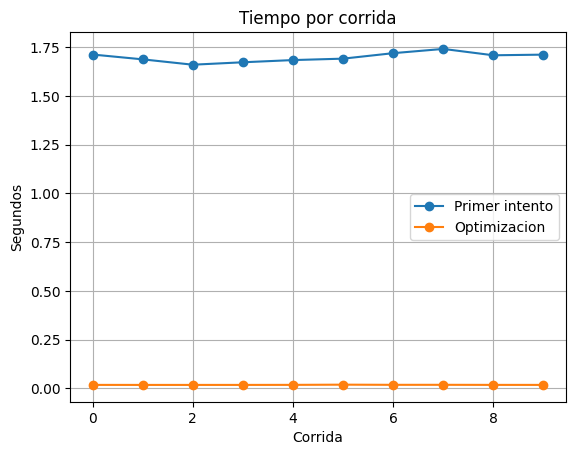

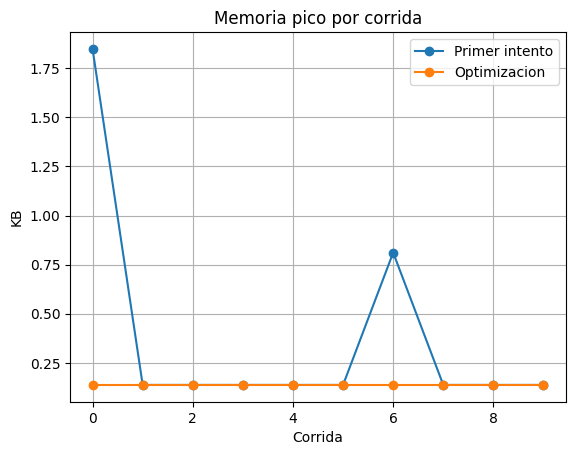

In [15]:
import time
import tracemalloc
import matplotlib.pyplot as plt


def medir(funcion, corridas=10):
    tiempos = []
    memorias = []
    resultados = []

    for _ in range(corridas):
        tracemalloc.start()

        tiempo_inicial = time.process_time()
        resultado = funcion()
        tiempo_final = time.process_time()

        _, memoria_pico = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        tiempos.append(tiempo_final - tiempo_inicial)
        memorias.append(memoria_pico / 1024)
        resultados.append(resultado)

    return {
        "resultado": resultados[0] if len(set(resultados)) == 1 else None,
        "consistente": len(set(resultados)) == 1,
        "tiempos": tiempos,
        "memorias": memorias,
    }


metodos = {
    "Primer intento": primer_intento,
    "Optimizacion": optimizacion,
}

comparaciones = {
    nombre: medir(funcion, corridas=10)
    for nombre, funcion in metodos.items()
}

for nombre, datos in comparaciones.items():
    print(f"\n--- {nombre} ---")
    print("Resultado:", datos["resultado"])
    print("Consistente:", datos["consistente"])
    print(f"Tiempo promedio: {sum(datos['tiempos']) / len(datos['tiempos']):.6f} s")
    print(f"Tiempo minimo: {min(datos['tiempos']):.6f} s")
    print(f"Memoria promedio: {sum(datos['memorias']) / len(datos['memorias']):.2f} KB")
    print(f"Memoria maxima: {max(datos['memorias']):.2f} KB")


plt.figure()
for nombre, datos in comparaciones.items():
    plt.plot(datos["tiempos"], marker="o", label=nombre)
plt.title("Tiempo por corrida")
plt.xlabel("Corrida")
plt.ylabel("Segundos")
plt.legend()
plt.grid()

plt.figure()
for nombre, datos in comparaciones.items():
    plt.plot(datos["memorias"], marker="o", label=nombre)
plt.title("Memoria pico por corrida")
plt.xlabel("Corrida")
plt.ylabel("KB")
plt.legend()
plt.grid()

plt.show()